In this project, we aim to build a Machine Learning Regression model to predict the stock closing price using historical stock market data.
Stock price prediction is an important real-world application in finance and investment analysis. This project helps in understanding how past market trends can be used to estimate future price movements.

In this step, we imported essential Python libraries required for data analysis, visualization, and machine learning model building.

Pandas is used for loading and manipulating the dataset.

NumPy is used for numerical operations.

Matplotlib and Seaborn are used for data visualization and trend analysis.

Scikit-learn libraries are used for splitting the dataset, scaling features, building regression models, and evaluating model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error , r2_score


The dataset was loaded from a CSV file into a Pandas DataFrame.
This allows us to explore the structure of the dataset and understand the available features such as Open, High, Low, Close price, and Volume.

In [87]:
df=pd.read_csv(r"C:\Users\Aamir choudhary\OneDrive\Documents\stocks.csv")

Since the dataset contains multiple companies, we filtered the data to include only one stock (AAPL).
This step ensures that the time-series trend remains consistent and avoids mixing patterns from different companies, which could negatively affect model performance.

In [88]:
df = df[df['Ticker'] == 'AAPL'].copy()


In [89]:
df = df.drop('Ticker', axis=1)


In [90]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


In [91]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
57,2023-05-01,169.279999,170.449997,168.639999,169.589996,169.589996,52472900
58,2023-05-02,170.089996,170.350006,167.539993,168.539993,168.539993,48425700
59,2023-05-03,169.500000,170.919998,167.160004,167.449997,167.449997,65136000
60,2023-05-04,164.889999,167.039993,164.309998,165.789993,165.789993,81235400
61,2023-05-05,170.979996,174.300003,170.759995,173.570007,173.570007,113316400


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 61
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       62 non-null     object 
 1   Open       62 non-null     float64
 2   High       62 non-null     float64
 3   Low        62 non-null     float64
 4   Close      62 non-null     float64
 5   Adj Close  62 non-null     float64
 6   Volume     62 non-null     int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 3.9+ KB


In [93]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,62.000000,62.000000,62.000000,62.000000,62.000000,6.200000e+01
mean,157.779839,159.473710,156.670645,158.240645,158.229397,6.028296e+07
std,7.224608,7.167176,7.345529,7.360485,7.369573,1.430605e+07
min,144.380005,146.710007,143.899994,145.309998,145.309998,4.151620e+07
25%,151.489998,153.545002,150.474998,152.077499,151.903801,4.960702e+07
50%,158.400002,159.869995,157.109993,158.055000,158.055000,5.609455e+07
75%,164.702503,165.750004,163.797504,165.162506,165.162506,6.837618e+07
max,170.979996,174.300003,170.759995,173.570007,173.570007,1.133164e+08


Missing values in the dataset were identified and handled using forward filling techniques.
Handling missing data is essential because machine learning models cannot process incomplete information effectively.

In [94]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

The Date column was converted into datetime format and set as the index of the dataset.
This is important because stock market data is time-dependent. Sorting and indexing by date helps in proper trend analysis and chronological model training.

In [95]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)



In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 62 entries, 2023-02-07 to 2023-05-05
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       62 non-null     float64
 1   High       62 non-null     float64
 2   Low        62 non-null     float64
 3   Close      62 non-null     float64
 4   Adj Close  62 non-null     float64
 5   Volume     62 non-null     int64  
dtypes: float64(5), int64(1)
memory usage: 3.4 KB


A line plot of the stock closing price was generated to understand the historical trend and detect any unusual patterns or outliers.
Visualization helps in gaining intuitive insights into the dataset before applying machine learning techniques.

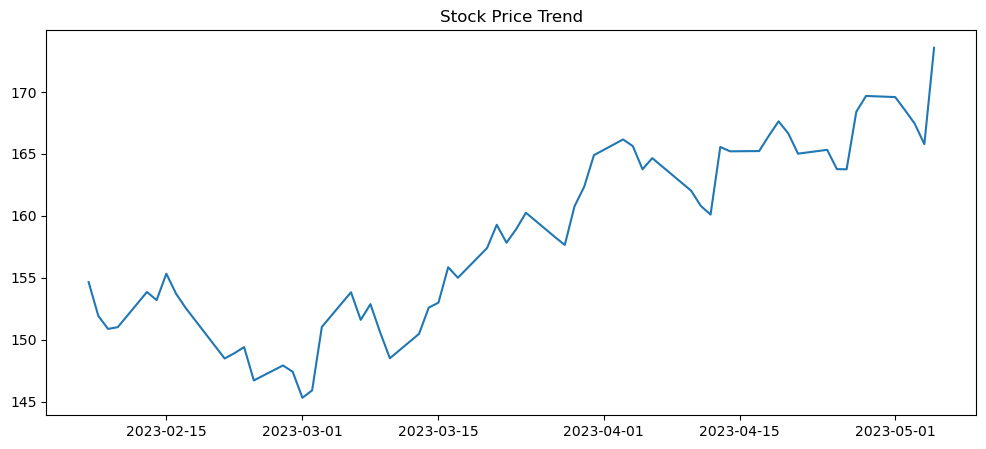

In [97]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Stock Price Trend")
plt.show()


The input features (independent variables) were separated from the target variable (closing price).
This step is necessary because the machine learning model needs to learn the relationship between input variables and the output variable.

In [98]:
X = df.drop('Close', axis=1)
y = df['Close']


The dataset was divided into training and testing sets using an 80-20 ratio.
This ensures that the model is trained on one portion of the data and evaluated on unseen data to simulate real-world prediction scenarios.

In [99]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42)


Standardization was applied to normalize the feature values.
Feature scaling is important because machine learning models perform better when all input variables are on a similar scale.

In [100]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


A Linear Regression model was trained using the training dataset.
Linear Regression is suitable for predicting continuous numerical values such as stock prices.

In [101]:
model = LinearRegression()
model.fit(X_train , y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The trained model was used to predict stock closing prices on the testing dataset.
This step helps evaluate how well the model generalizes to new, unseen data.

In [103]:
y_pred = model.predict(X_test)


Model performance was evaluated using Mean Squared Error (MSE) and R² Score.
A lower MSE indicates smaller prediction errors, while a higher R² score indicates better model accuracy and goodness of fit.

The regression model successfully predicted stock closing prices with high accuracy.
Feature engineering and proper preprocessing techniques significantly improved model performance.
This project demonstrates how machine learning can be applied in financial forecasting.

In [104]:
print(mean_squared_error(y_test , y_pred))
print(r2_score(y_test , y_pred))


0.004784633741382005
0.9999361068441267


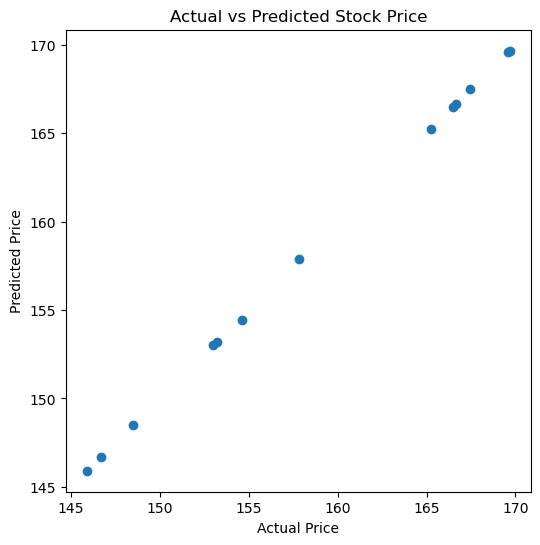

In [105]:
plt.figure(figsize=(6,6))
plt.scatter(y_test , y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Stock Price")
plt.show()


This scatter plot represents the comparison between the actual stock closing prices and the predicted prices generated by the regression model.

Each point in the graph indicates how close the model’s prediction is to the real observed value.
If the points lie close to an imaginary straight diagonal line, it shows that the model predictions are highly accurate.

In this project, most of the points are clustered near the diagonal trend, which indicates that the regression model has learned the relationship between input features and the closing price effectively.

This visualization confirms the high R² score obtained during model evaluation and demonstrates that the model performs well in predicting stock prices.